# 🍽️ Zomato / Swiggy Restaurant Success Predictor
## Phase 1 — Exploratory Data Analysis (EDA)

**Tools:** Python · pandas · numpy · matplotlib · seaborn · scikit-learn  
**Dataset:** 500 restaurants · 8 Indian cities · 20 features  
**Goal:** Understand what makes a restaurant Thrive, Struggle, or Close

---
### Project Structure
```
zomato_project/
├── data/
│   ├── raw/zomato_swiggy_dataset.csv
│   └── cleaned/zomato_cleaned.csv
├── notebooks/
│   └── 01_EDA.ipynb  ← you are here
├── charts/           ← auto-created by this notebook
├── sql/
└── powerbi/
```


## 📦 Cell 1 — Imports & Display Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings("ignore")

# ── Display settings ──────────────────────────────────────────────
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({
    "figure.figsize"  : (12, 6),
    "figure.dpi"      : 120,
    "font.family"     : "DejaVu Sans",
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "axes.grid"       : True,
    "grid.alpha"      : 0.3,
})
sns.set_palette("husl")

# ── Color scheme (consistent across all charts) ───────────────────
STATUS_COLORS = {
    "Thriving"  : "#27AE60",
    "Stable"    : "#2980B9",
    "Struggling": "#E67E22",
    "Closed"    : "#E74C3C"
}
STATUS_ORDER = ["Thriving", "Stable", "Struggling", "Closed"]

# ── Create output folders ─────────────────────────────────────────
os.makedirs("../charts", exist_ok=True)
os.makedirs("../data/cleaned", exist_ok=True)

print("✅ All imports successful")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")


✅ All imports successful
   pandas  3.0.3
   numpy   2.4.6
   seaborn 0.13.2


## 📂 Cell 2 — Load & First Look at Data

In [3]:
# ── Load dataset ──────────────────────────────────────────────────
df = pd.read_csv("../data/raw/zomato_swiggy_dataset.csv")

print(f"Shape        : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory usage : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("\n── Column dtypes ──")
print(df.dtypes)
print("\n── First 5 rows ──")
df.head()


Shape        : 500 rows × 20 columns
Memory usage : 336.5 KB

── Column dtypes ──
Restaurant_ID                 str
Restaurant_Name               str
City                          str
Area                          str
Cuisine_Type                  str
Restaurant_Type               str
Price_Range                   str
Rating                    float64
Total_Reviews               int64
Avg_Delivery_Time_Min       int64
Monthly_Orders              int64
Avg_Order_Value_INR         int64
Years_Active              float64
Review_Sentiment_Score    float64
Discount_Offered_Pct        int64
On_Zomato                     str
On_Swiggy                     str
Staff_Count                 int64
Success_Score             float64
Status                        str
dtype: object

── First 5 rows ──


,Restaurant_ID,Restaurant_Name,City,Area,Cuisine_Type,Restaurant_Type,Price_Range,Rating,Total_Reviews,Avg_Delivery_Time_Min,Monthly_Orders,Avg_Order_Value_INR,Years_Active,Review_Sentiment_Score,Discount_Offered_Pct,On_Zomato,On_Swiggy,Staff_Count,Success_Score,Status
0,R0001,Restaurant_1,Mumbai,Bandra,Fast Food,Delivery Only,Mid-range (₹200-₹500),2.80,889,63,2333,269,6.10,-0.74,0,Yes,Yes,35,25.80,Struggling
1,R0002,Restaurant_2,Kolkata,Salt Lake,Mughlai,Fine Dining,Premium (₹500-₹1000),4.50,103,68,753,894,4.50,-0.30,10,Yes,Yes,8,38.70,Closed
2,R0003,Restaurant_3,Pune,Baner,Fast Food,Dine-in,Luxury (> ₹1000),3.80,3150,25,2361,480,8.40,0.31,20,Yes,Yes,5,65.00,Stable
3,R0004,Restaurant_4,Chennai,T Nagar,Italian,Dine-in,Luxury (> ₹1000),3.20,3038,30,1616,543,2.50,-0.32,0,Yes,Yes,13,43.10,Struggling
4,R0005,Restaurant_5,Chennai,Mylapore,Street Food,Delivery Only,Premium (₹500-₹1000),4.60,508,34,231,1004,3.50,-0.32,10,Yes,Yes,44,48.40,Stable


## 🔍 Cell 3 — Data Quality Check

In [4]:
print("═" * 50)
print("  NULL VALUES")
print("═" * 50)
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "✅ No null values found")

print("\n" + "═" * 50)
print("  DUPLICATES")
print("═" * 50)
dupes = df.duplicated().sum()
print(f"✅ {dupes} duplicate rows" if dupes == 0 else f"⚠️  {dupes} duplicates found — will drop")

print("\n" + "═" * 50)
print("  STATISTICAL SUMMARY")
print("═" * 50)
df.describe().round(2)


══════════════════════════════════════════════════
  NULL VALUES
══════════════════════════════════════════════════
✅ No null values found

══════════════════════════════════════════════════
  DUPLICATES
══════════════════════════════════════════════════
✅ 0 duplicate rows

══════════════════════════════════════════════════
  STATISTICAL SUMMARY
══════════════════════════════════════════════════


,Rating,Total_Reviews,Avg_Delivery_Time_Min,Monthly_Orders,Avg_Order_Value_INR,Years_Active,Review_Sentiment_Score,Discount_Offered_Pct,Staff_Count,Success_Score
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,3.63,2555.59,47.85,1572.72,698.97,5.18,0.10,20.62,26.64,46.90
std,0.70,1418.08,16.27,828.53,286.67,2.76,0.50,16.20,13.74,15.01
min,2.50,88.00,20.00,118.00,180.00,0.50,-0.80,0.00,3.00,5.80
25%,3.00,1296.00,34.00,846.25,449.50,2.70,-0.31,10.00,15.00,36.30
50%,3.60,2574.50,48.00,1588.00,703.00,5.00,0.15,20.00,26.00,45.75
75%,4.20,3704.00,62.00,2295.25,944.25,7.70,0.50,30.00,39.00,57.22
max,5.00,4999.00,75.00,3000.00,1198.00,10.00,0.99,50.00,50.00,93.70


## 🧹 Cell 4 — Data Cleaning & Feature Engineering

In [5]:
df_clean = df.copy()

# ── Drop duplicates ───────────────────────────────────────────────
df_clean.drop_duplicates(inplace=True)

# ── Fix data types ────────────────────────────────────────────────
df_clean["Rating"]               = pd.to_numeric(df_clean["Rating"], errors="coerce")
df_clean["Monthly_Orders"]       = df_clean["Monthly_Orders"].astype(int)
df_clean["Years_Active"]         = df_clean["Years_Active"].astype(float)
df_clean["Success_Score"]        = df_clean["Success_Score"].astype(float)
df_clean["Review_Sentiment_Score"] = df_clean["Review_Sentiment_Score"].astype(float)

# ── Derived columns ───────────────────────────────────────────────
# 1. Monthly Revenue
df_clean["Monthly_Revenue"] = df_clean["Monthly_Orders"] * df_clean["Avg_Order_Value_INR"]

# 2. Revenue Band
df_clean["Revenue_Band"] = pd.cut(
    df_clean["Monthly_Revenue"],
    bins=[0, 500_000, 1_500_000, float("inf")],
    labels=["Low (<5L)", "Medium (5–15L)", "High (>15L)"]
)

# 3. Platform Presence
conditions = [
    (df_clean["On_Zomato"] == "Yes") & (df_clean["On_Swiggy"] == "Yes"),
    (df_clean["On_Zomato"] == "Yes") & (df_clean["On_Swiggy"] == "No"),
    (df_clean["On_Zomato"] == "No")  & (df_clean["On_Swiggy"] == "Yes"),
]
choices = ["Both Platforms", "Zomato Only", "Swiggy Only"]
df_clean["Dual_Platform"] = np.select(conditions, choices, default="No Platform")

# 4. Sentiment Category
df_clean["Sentiment_Category"] = pd.cut(
    df_clean["Review_Sentiment_Score"],
    bins=[-1.01, -0.3, 0.3, 1.01],
    labels=["Negative", "Neutral", "Positive"]
)

# 5. Delivery Speed Bucket
df_clean["Delivery_Speed"] = pd.cut(
    df_clean["Avg_Delivery_Time_Min"],
    bins=[0, 30, 45, 100],
    labels=["Fast (<30 min)", "Normal (30–45 min)", "Slow (>45 min)"]
)

# 6. Rating Band
df_clean["Rating_Band"] = pd.cut(
    df_clean["Rating"],
    bins=[0, 3.0, 3.5, 4.0, 4.5, 5.01],
    labels=["<3.0", "3.0–3.5", "3.5–4.0", "4.0–4.5", "4.5+"]
)

# ── Save cleaned CSV ──────────────────────────────────────────────
df_clean.to_csv("../data/cleaned/zomato_cleaned.csv", index=False)

print(f"✅ Cleaned dataset saved → data/cleaned/zomato_cleaned.csv")
print(f"   Original shape : {df.shape}")
print(f"   Cleaned shape  : {df_clean.shape}")
print(f"   New columns added: Monthly_Revenue, Revenue_Band, Dual_Platform,")
print(f"                      Sentiment_Category, Delivery_Speed, Rating_Band")
df_clean.head(3)


✅ Cleaned dataset saved → data/cleaned/zomato_cleaned.csv
   Original shape : (500, 20)
   Cleaned shape  : (500, 26)
   New columns added: Monthly_Revenue, Revenue_Band, Dual_Platform,
                      Sentiment_Category, Delivery_Speed, Rating_Band


,Restaurant_ID,Restaurant_Name,City,Area,Cuisine_Type,Restaurant_Type,Price_Range,Rating,Total_Reviews,Avg_Delivery_Time_Min,Monthly_Orders,Avg_Order_Value_INR,Years_Active,Review_Sentiment_Score,Discount_Offered_Pct,On_Zomato,On_Swiggy,Staff_Count,Success_Score,Status,Monthly_Revenue,Revenue_Band,Dual_Platform,Sentiment_Category,Delivery_Speed,Rating_Band
0,R0001,Restaurant_1,Mumbai,Bandra,Fast Food,Delivery Only,Mid-range (₹200-₹500),2.80,889,63,2333,269,6.10,-0.74,0,Yes,Yes,35,25.80,Struggling,627577,Medium (5–15L),Both Platforms,Negative,Slow (>45 min),<3.0
1,R0002,Restaurant_2,Kolkata,Salt Lake,Mughlai,Fine Dining,Premium (₹500-₹1000),4.50,103,68,753,894,4.50,-0.30,10,Yes,Yes,8,38.70,Closed,673182,Medium (5–15L),Both Platforms,Negative,Slow (>45 min),4.0–4.5
2,R0003,Restaurant_3,Pune,Baner,Fast Food,Dine-in,Luxury (> ₹1000),3.80,3150,25,2361,480,8.40,0.31,20,Yes,Yes,5,65.00,Stable,1133280,Medium (5–15L),Both Platforms,Positive,Fast (<30 min),3.5–4.0


## 📊 Chart 1 — Restaurant Status Distribution
**Question:** What percentage of restaurants are thriving vs closed?

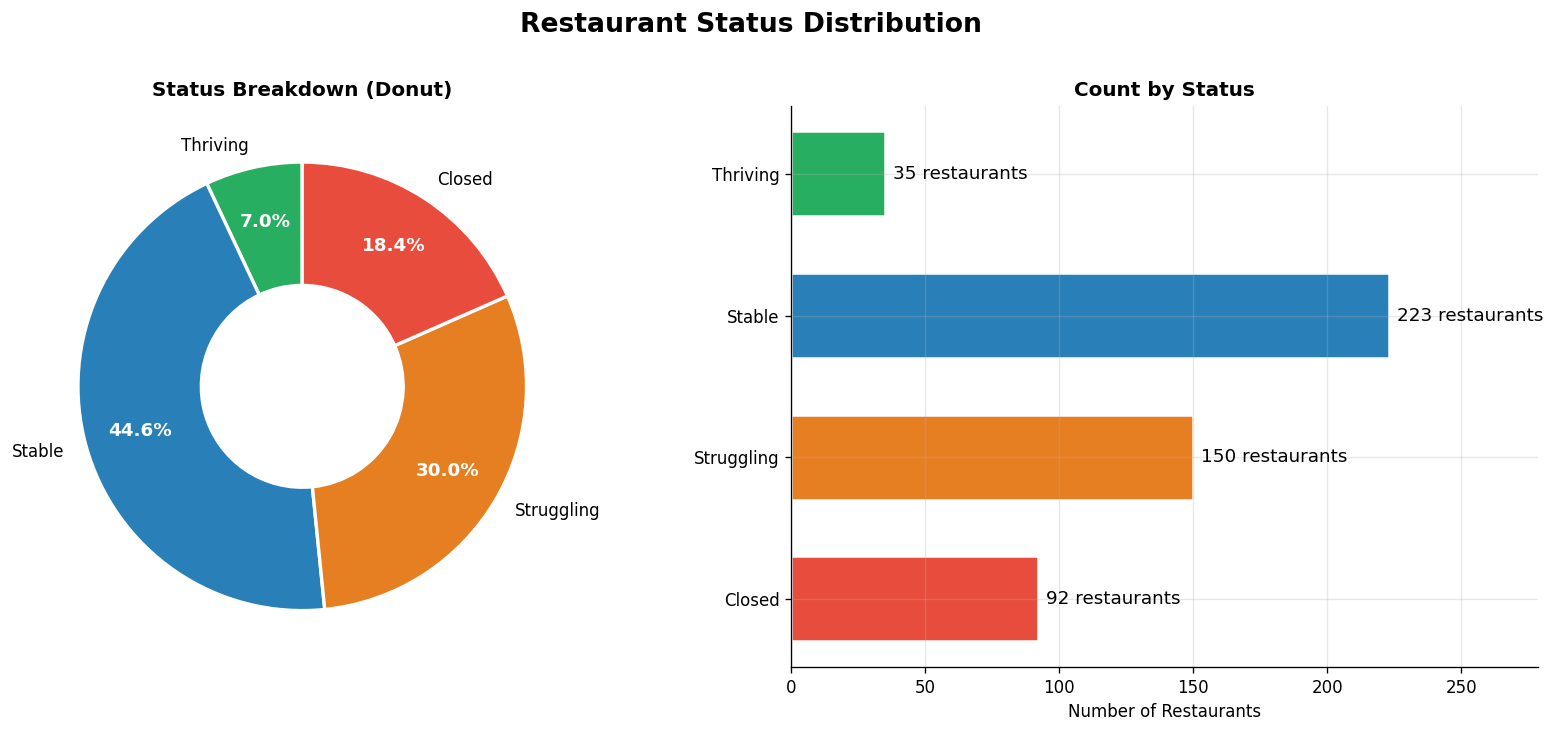


📌 KEY INSIGHT: Overall survival rate = 81.6%
   Thriving : 35 (7.0%)
   Closed   : 92   (18.4%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Restaurant Status Distribution", fontsize=16, fontweight="bold", y=1.01)

# ── Left: Donut chart ─────────────────────────────────────────────
status_counts = df_clean["Status"].value_counts().reindex(STATUS_ORDER)
colors = [STATUS_COLORS[s] for s in STATUS_ORDER]

wedges, texts, autotexts = axes[0].pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")
axes[0].set_title("Status Breakdown (Donut)", fontweight="bold")

# ── Right: Horizontal bar ─────────────────────────────────────────
bars = axes[1].barh(
    STATUS_ORDER[::-1],
    [status_counts[s] for s in STATUS_ORDER[::-1]],
    color=[STATUS_COLORS[s] for s in STATUS_ORDER[::-1]],
    edgecolor="white", linewidth=1.5, height=0.6
)
for bar, val in zip(bars, [status_counts[s] for s in STATUS_ORDER[::-1]]):
    axes[1].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
                 f"{val} restaurants", va="center", fontsize=11)
axes[1].set_xlabel("Number of Restaurants")
axes[1].set_title("Count by Status", fontweight="bold")
axes[1].set_xlim(0, max(status_counts) * 1.25)

plt.tight_layout()
plt.savefig("../charts/01_status_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Key stat ──────────────────────────────────────────────────────
survival = 100 * (df_clean["Status"] != "Closed").sum() / len(df_clean)
print(f"\n📌 KEY INSIGHT: Overall survival rate = {survival:.1f}%")
print(f"   Thriving : {status_counts['Thriving']} ({100*status_counts['Thriving']/len(df_clean):.1f}%)")
print(f"   Closed   : {status_counts['Closed']}   ({100*status_counts['Closed']/len(df_clean):.1f}%)")


## 🏙️ Chart 2 — City-wise Restaurant Status
**Question:** Which Indian city has the healthiest restaurant ecosystem?

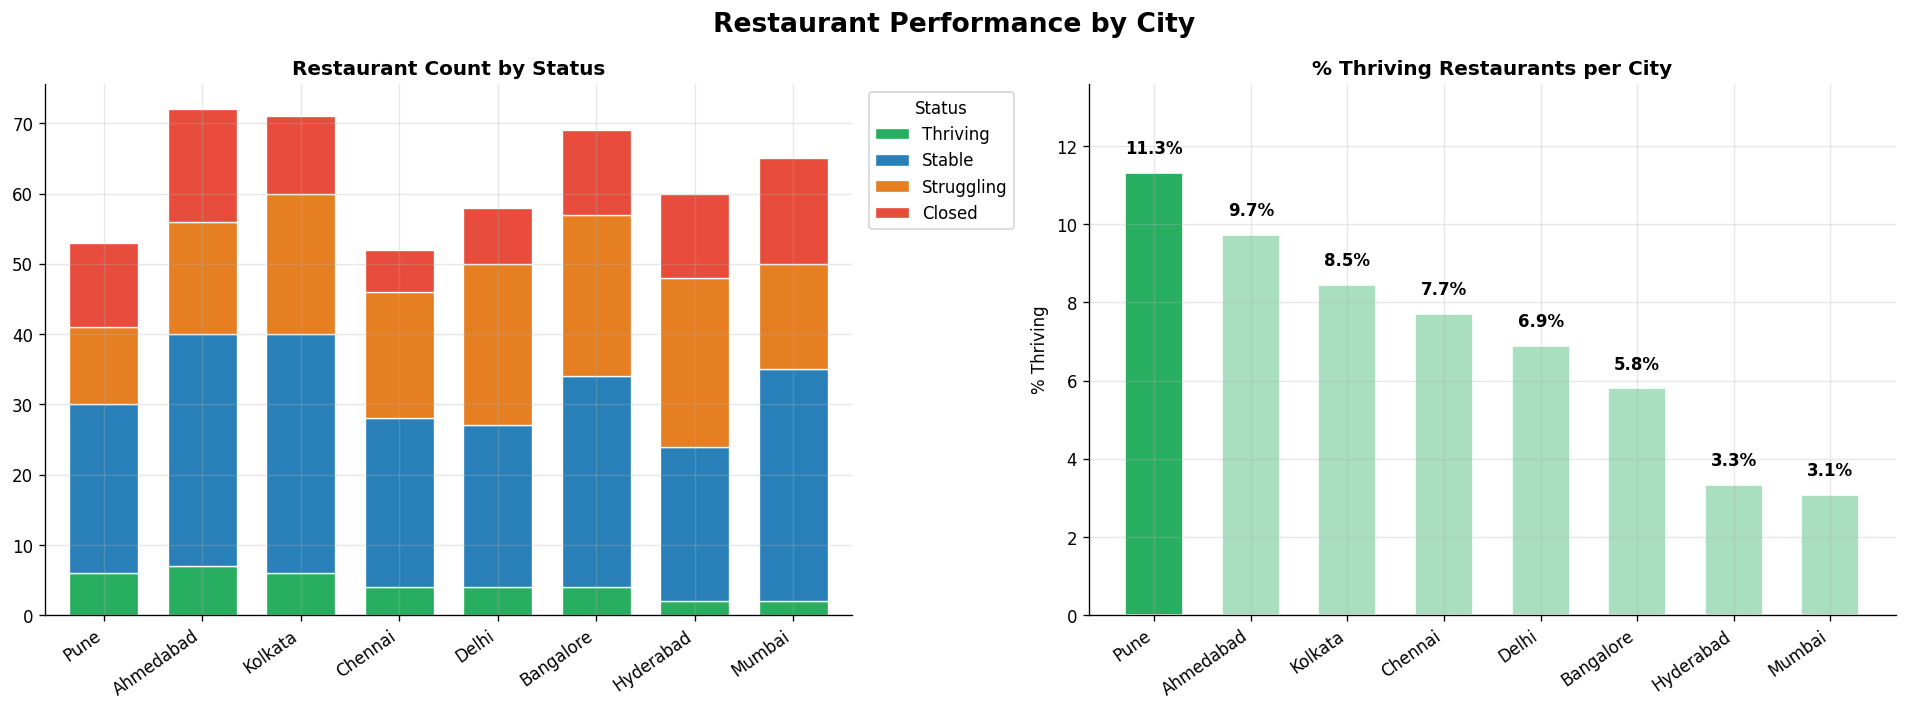


📌 KEY INSIGHT: Best city = Pune (11.3% thriving)
   City survival rates:
   Pune         → 11.3% thriving
   Ahmedabad    → 9.7% thriving
   Kolkata      → 8.5% thriving
   Chennai      → 7.7% thriving
   Delhi        → 6.9% thriving
   Bangalore    → 5.8% thriving
   Hyderabad    → 3.3% thriving
   Mumbai       → 3.1% thriving


In [7]:
city_status = (df_clean.groupby(["City", "Status"])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=STATUS_ORDER))
city_status_pct = city_status.div(city_status.sum(axis=1), axis=0) * 100
city_order = city_status_pct["Thriving"].sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Restaurant Performance by City", fontsize=16, fontweight="bold")

# ── Left: Stacked count ───────────────────────────────────────────
city_status.loc[city_order].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=[STATUS_COLORS[s] for s in STATUS_ORDER],
    edgecolor="white", linewidth=0.8, width=0.7
)
axes[0].set_title("Restaurant Count by Status", fontweight="bold")
axes[0].set_xlabel(""); axes[0].set_xticklabels(city_order, rotation=35, ha="right")
axes[0].legend(title="Status", bbox_to_anchor=(1.01, 1), loc="upper left")

# ── Right: % Thriving bar ─────────────────────────────────────────
thriving_pct = city_status_pct.loc[city_order, "Thriving"]
bars = axes[1].bar(city_order, thriving_pct,
                   color=[STATUS_COLORS["Thriving"] if v == thriving_pct.max()
                          else "#A9DFBF" for v in thriving_pct],
                   edgecolor="white", width=0.6)
for bar, val in zip(bars, thriving_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("% Thriving Restaurants per City", fontweight="bold")
axes[1].set_ylabel("% Thriving"); axes[1].set_ylim(0, max(thriving_pct) * 1.2)
axes[1].set_xticklabels(city_order, rotation=35, ha="right")

plt.tight_layout()
plt.savefig("../charts/02_city_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

best_city = thriving_pct.idxmax()
print(f"\n📌 KEY INSIGHT: Best city = {best_city} ({thriving_pct.max():.1f}% thriving)")
print(f"   City survival rates:")
for city in city_order:
    print(f"   {city:12s} → {thriving_pct[city]:.1f}% thriving")


## ⭐ Chart 3 — Rating & Success Score Distribution
**Question:** What rating range do thriving restaurants cluster in?

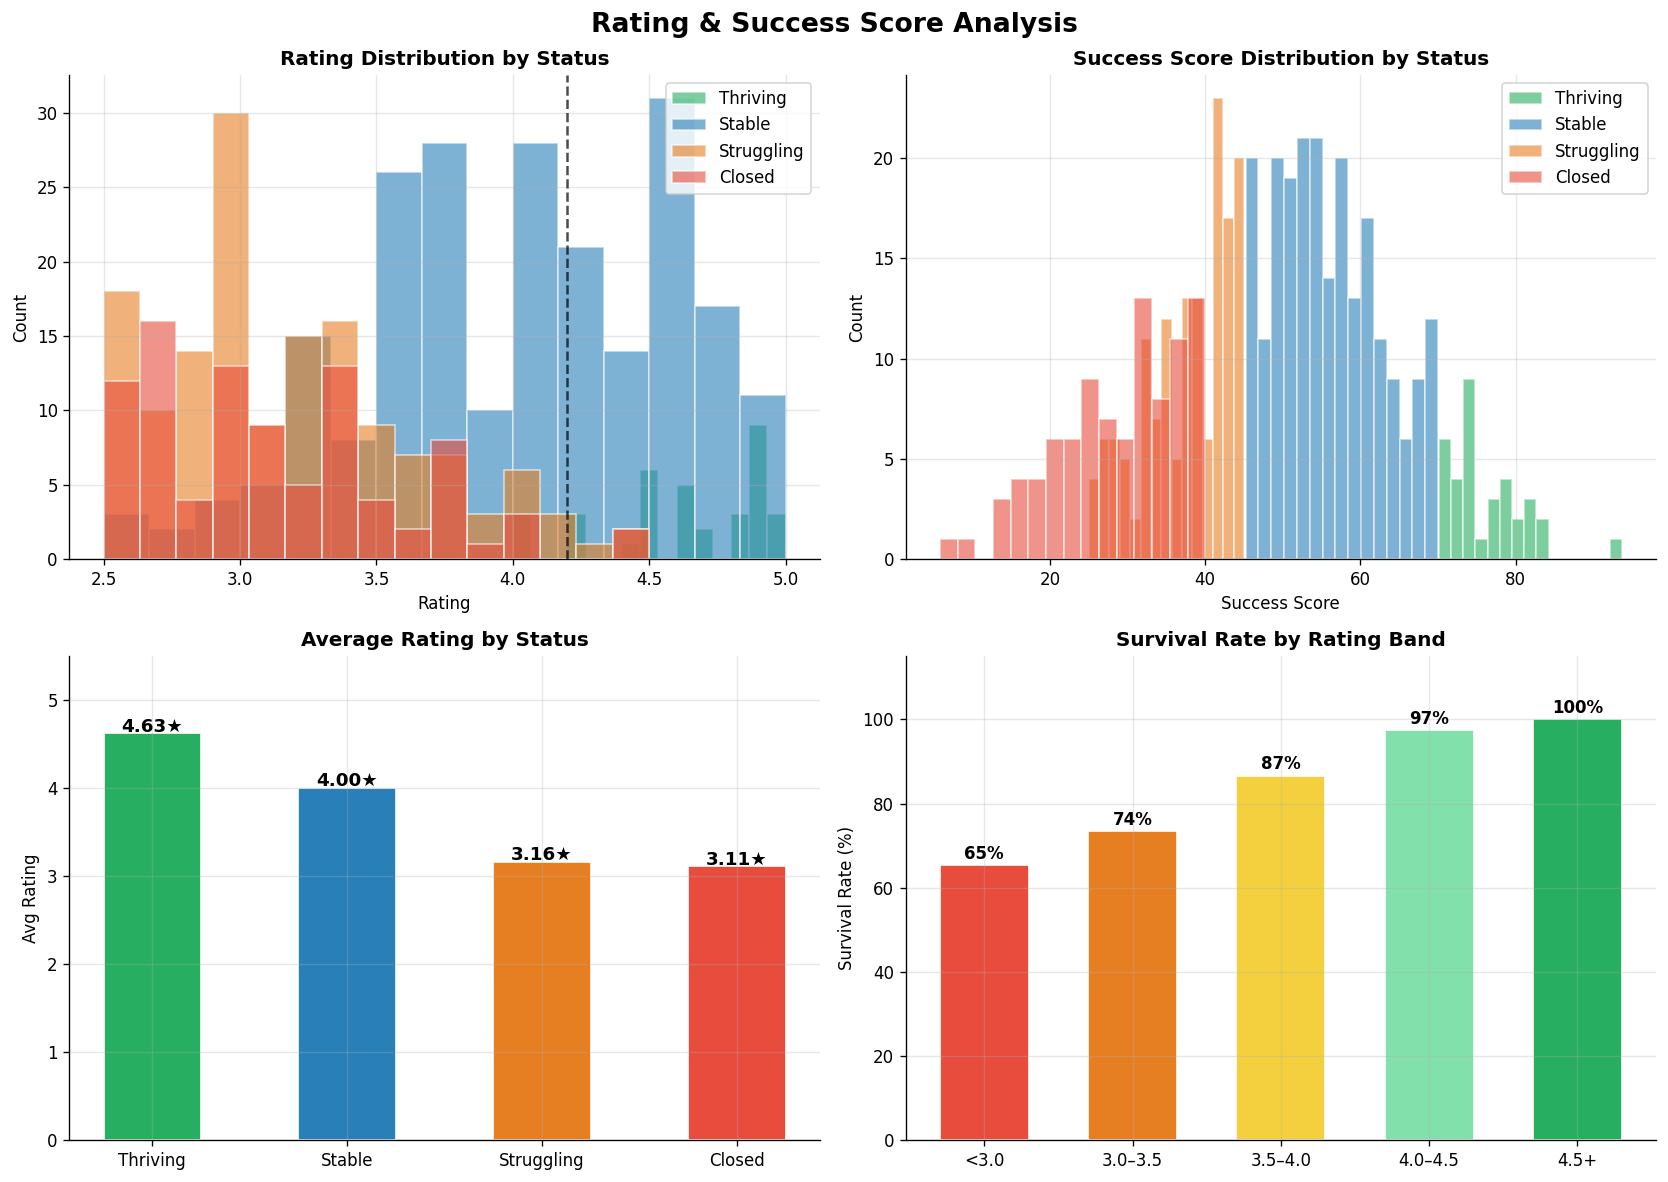


📌 KEY INSIGHTS:
   Thriving     avg rating = 4.63
   Stable       avg rating = 4.00
   Struggling   avg rating = 3.16
   Closed       avg rating = 3.11


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Rating & Success Score Analysis", fontsize=16, fontweight="bold")

# ── Top-left: Rating histogram by status ─────────────────────────
for status in STATUS_ORDER:
    subset = df_clean[df_clean["Status"] == status]["Rating"]
    axes[0,0].hist(subset, bins=15, alpha=0.6, label=status,
                   color=STATUS_COLORS[status], edgecolor="white")
axes[0,0].set_title("Rating Distribution by Status", fontweight="bold")
axes[0,0].set_xlabel("Rating"); axes[0,0].set_ylabel("Count")
axes[0,0].legend()
axes[0,0].axvline(4.2, color="black", linestyle="--", alpha=0.7, label="4.2 threshold")

# ── Top-right: Success score histogram ───────────────────────────
for status in STATUS_ORDER:
    subset = df_clean[df_clean["Status"] == status]["Success_Score"]
    axes[0,1].hist(subset, bins=15, alpha=0.6, label=status,
                   color=STATUS_COLORS[status], edgecolor="white")
axes[0,1].set_title("Success Score Distribution by Status", fontweight="bold")
axes[0,1].set_xlabel("Success Score"); axes[0,1].set_ylabel("Count")
axes[0,1].legend()

# ── Bottom-left: Avg rating by status (bar) ───────────────────────
avg_rating = df_clean.groupby("Status")["Rating"].mean().reindex(STATUS_ORDER)
bars = axes[1,0].bar(STATUS_ORDER, avg_rating,
                     color=[STATUS_COLORS[s] for s in STATUS_ORDER],
                     edgecolor="white", width=0.5)
for bar, val in zip(bars, avg_rating):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f"{val:.2f}★", ha="center", fontweight="bold", fontsize=11)
axes[1,0].set_title("Average Rating by Status", fontweight="bold")
axes[1,0].set_ylabel("Avg Rating"); axes[1,0].set_ylim(0, 5.5)

# ── Bottom-right: Rating band survival ────────────────────────────
rating_survival = df_clean.groupby("Rating_Band").apply(
    lambda x: 100 * (x["Status"] != "Closed").sum() / len(x)
).reset_index(name="Survival_Rate")
axes[1,1].bar(rating_survival["Rating_Band"].astype(str),
              rating_survival["Survival_Rate"],
              color=["#E74C3C","#E67E22","#F4D03F","#82E0AA","#27AE60"],
              edgecolor="white", width=0.6)
axes[1,1].set_title("Survival Rate by Rating Band", fontweight="bold")
axes[1,1].set_ylabel("Survival Rate (%)"); axes[1,1].set_ylim(0, 115)
for i, row in rating_survival.iterrows():
    axes[1,1].text(i, row["Survival_Rate"] + 1.5, f"{row['Survival_Rate']:.0f}%",
                   ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../charts/03_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 KEY INSIGHTS:")
for s in STATUS_ORDER:
    r = df_clean[df_clean["Status"]==s]["Rating"].mean()
    print(f"   {s:12s} avg rating = {r:.2f}")


## 🎯 Chart 4 — Rating vs Success Score (Bubble Chart)
**Question:** What is the relationship between rating and success score? This is the most important chart in the project.

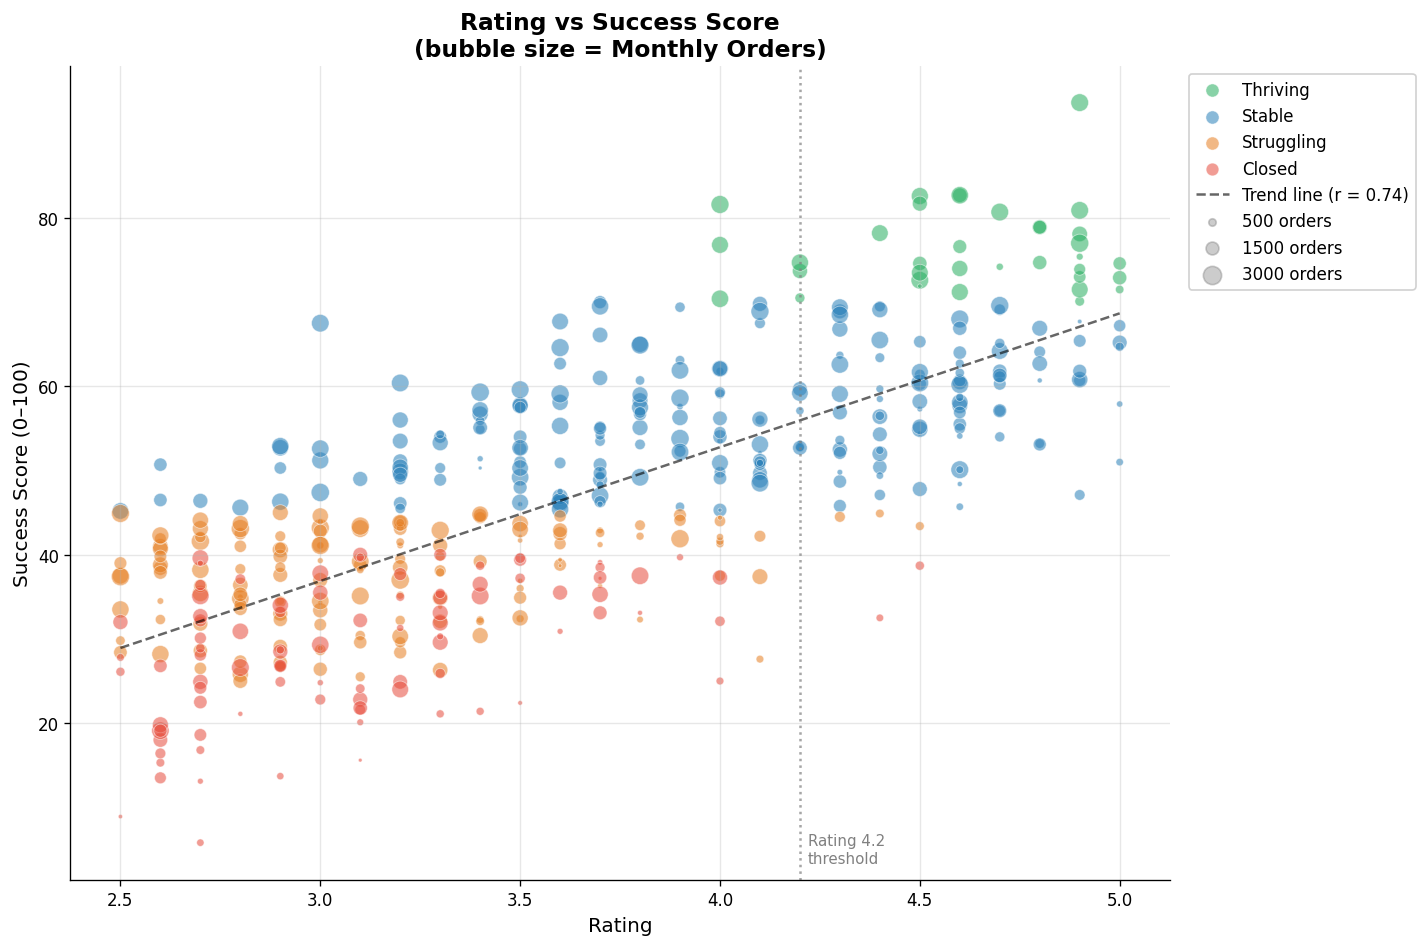


📌 KEY INSIGHT: Pearson correlation (Rating ↔ Success Score) = 0.744
   p-value = 0.0000 (statistically significant ✅)


In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

for status in STATUS_ORDER:
    subset = df_clean[df_clean["Status"] == status]
    scatter = ax.scatter(
        subset["Rating"],
        subset["Success_Score"],
        s=subset["Monthly_Orders"] / 25,       # bubble size = monthly orders
        c=STATUS_COLORS[status],
        alpha=0.55,
        label=status,
        edgecolors="white",
        linewidth=0.5
    )

# ── Regression line ───────────────────────────────────────────────
slope, intercept, r, p, _ = stats.linregress(df_clean["Rating"], df_clean["Success_Score"])
x_line = np.linspace(df_clean["Rating"].min(), df_clean["Rating"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, "k--", alpha=0.6, linewidth=1.5,
        label=f"Trend line (r = {r:.2f})")

# ── Threshold line ────────────────────────────────────────────────
ax.axvline(4.2, color="gray", linestyle=":", alpha=0.7, linewidth=1.5)
ax.text(4.22, ax.get_ylim()[0] + 2, 'Rating 4.2\nthreshold', fontsize=9, color='gray')

# ── Bubble size legend ────────────────────────────────────────────
for orders, label in [(500, "500 orders"), (1500, "1500 orders"), (3000, "3000 orders")]:
    ax.scatter([], [], s=orders/25, c="gray", alpha=0.4, label=label)

ax.set_xlabel("Rating", fontsize=12)
ax.set_ylabel("Success Score (0–100)", fontsize=12)
ax.set_title("Rating vs Success Score\n(bubble size = Monthly Orders)",
             fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.savefig("../charts/04_rating_vs_success_bubble.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📌 KEY INSIGHT: Pearson correlation (Rating ↔ Success Score) = {r:.3f}")
print(f"   p-value = {p:.4f} {'(statistically significant ✅)' if p < 0.05 else ''}")


## 🚴 Chart 5 — Delivery Time vs Restaurant Status
**Question:** Do thriving restaurants deliver faster?

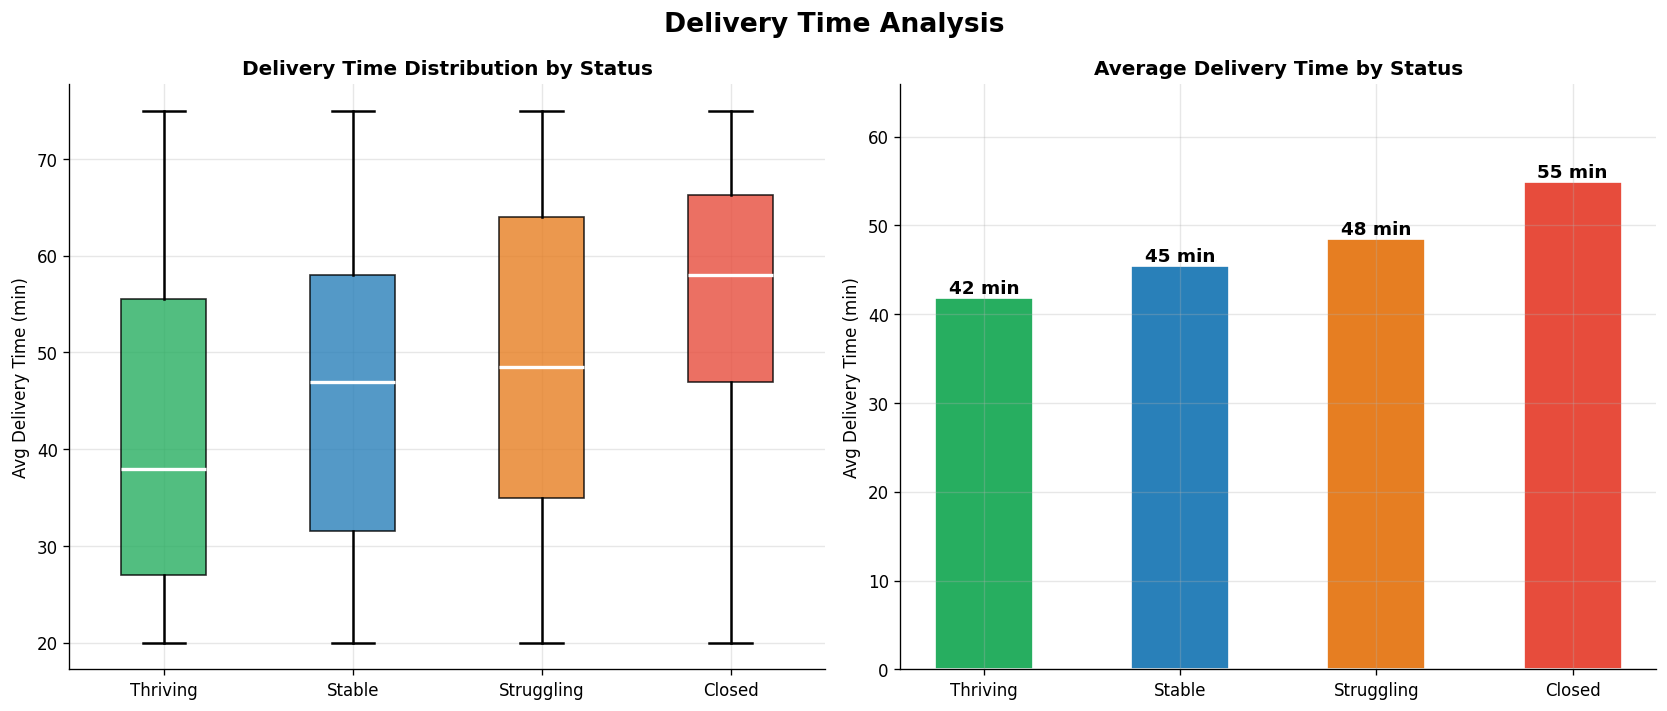


📌 KEY INSIGHTS:
   Thriving     avg delivery = 42 min
   Stable       avg delivery = 45 min
   Struggling   avg delivery = 48 min
   Closed       avg delivery = 55 min

   Thriving restaurants deliver 13 min faster than Closed ones


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Delivery Time Analysis", fontsize=16, fontweight="bold")

# ── Left: Box plot ────────────────────────────────────────────────
bp = axes[0].boxplot(
    [df_clean[df_clean["Status"]==s]["Avg_Delivery_Time_Min"].values for s in STATUS_ORDER],
    labels=STATUS_ORDER,
    patch_artist=True,
    medianprops={"color": "white", "linewidth": 2},
    whiskerprops={"linewidth": 1.5},
    capprops={"linewidth": 1.5}
)
for patch, status in zip(bp["boxes"], STATUS_ORDER):
    patch.set_facecolor(STATUS_COLORS[status])
    patch.set_alpha(0.8)
axes[0].set_title("Delivery Time Distribution by Status", fontweight="bold")
axes[0].set_ylabel("Avg Delivery Time (min)")

# ── Right: Avg delivery time bar ─────────────────────────────────
avg_delivery = df_clean.groupby("Status")["Avg_Delivery_Time_Min"].mean().reindex(STATUS_ORDER)
bars = axes[1].bar(STATUS_ORDER, avg_delivery,
                   color=[STATUS_COLORS[s] for s in STATUS_ORDER],
                   edgecolor="white", width=0.5)
for bar, val in zip(bars, avg_delivery):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.0f} min", ha="center", fontweight="bold", fontsize=11)
axes[1].set_title("Average Delivery Time by Status", fontweight="bold")
axes[1].set_ylabel("Avg Delivery Time (min)")
axes[1].set_ylim(0, max(avg_delivery) * 1.2)

plt.tight_layout()
plt.savefig("../charts/05_delivery_time_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 KEY INSIGHTS:")
for s in STATUS_ORDER:
    d = df_clean[df_clean["Status"]==s]["Avg_Delivery_Time_Min"].mean()
    print(f"   {s:12s} avg delivery = {d:.0f} min")
gap = avg_delivery["Closed"] - avg_delivery["Thriving"]
print(f"\n   Thriving restaurants deliver {gap:.0f} min faster than Closed ones")


## 📱 Chart 6 — Platform Presence Impact
**Question:** Is being on both Zomato and Swiggy worth it?

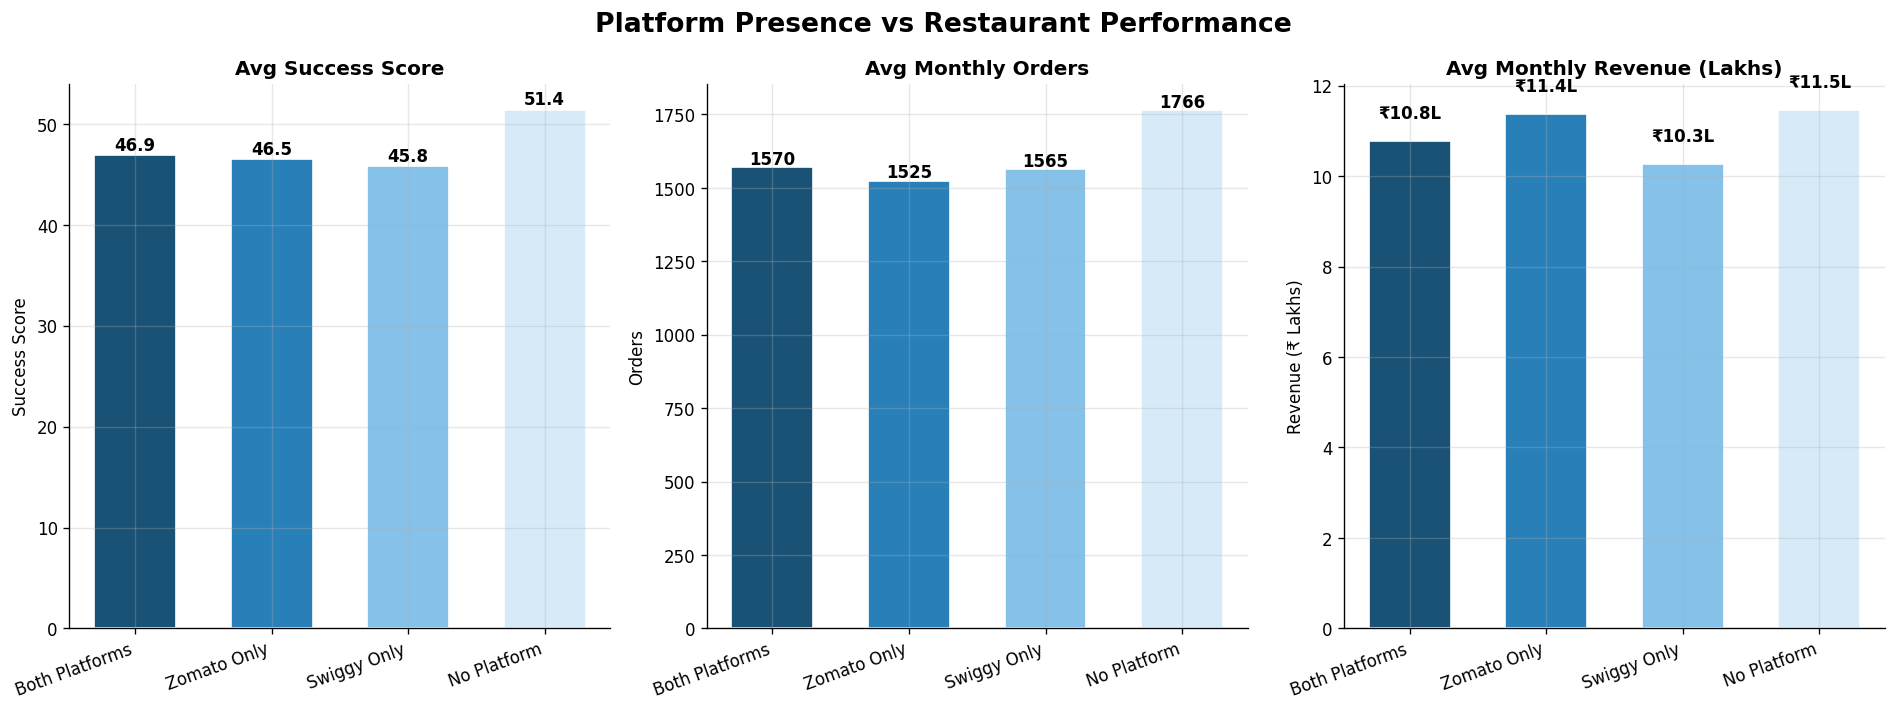


📌 KEY INSIGHT: Both-platform restaurants get 0.9x more orders than no-platform

   Full breakdown:
 Dual_Platform  Count  Avg_Success  Avg_Orders  Avg_Revenue
Both Platforms    273        46.90     1570.00   1077996.70
   Zomato Only    102        46.50     1524.70   1138085.80
   Swiggy Only     92        45.80     1564.90   1026384.40
   No Platform     33        51.40     1765.50   1146246.20


In [14]:
platform_order = ["Both Platforms", "Zomato Only", "Swiggy Only", "No Platform"]
platform_grp = (df_clean.groupby("Dual_Platform")
                .agg(
                    Avg_Success   = ("Success_Score", "mean"),
                    Avg_Orders    = ("Monthly_Orders", "mean"),
                    Avg_Revenue   = ("Monthly_Revenue", "mean"),
                    Count         = ("Restaurant_ID", "count")
                )
                .reindex(platform_order)
                .round(1)
                .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Platform Presence vs Restaurant Performance", fontsize=16, fontweight="bold")

pal = ["#1A5276", "#2980B9", "#85C1E9", "#D6EAF8"]

# ── Avg Success Score ─────────────────────────────────────────────
bars = axes[0].bar(platform_grp["Dual_Platform"], platform_grp["Avg_Success"],
                   color=pal, edgecolor="white", width=0.6)
for bar, val in zip(bars, platform_grp["Avg_Success"]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val:.1f}", ha="center", fontweight="bold")
axes[0].set_title("Avg Success Score", fontweight="bold")
axes[0].set_ylabel("Success Score"); axes[0].set_xticklabels(platform_order, rotation=20, ha="right")

# ── Avg Monthly Orders ────────────────────────────────────────────
bars = axes[1].bar(platform_grp["Dual_Platform"], platform_grp["Avg_Orders"],
                   color=pal, edgecolor="white", width=0.6)
for bar, val in zip(bars, platform_grp["Avg_Orders"]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f"{val:.0f}", ha="center", fontweight="bold")
axes[1].set_title("Avg Monthly Orders", fontweight="bold")
axes[1].set_ylabel("Orders"); axes[1].set_xticklabels(platform_order, rotation=20, ha="right")

# ── Avg Monthly Revenue ───────────────────────────────────────────
bars = axes[2].bar(platform_grp["Dual_Platform"], platform_grp["Avg_Revenue"]/100000,
                   color=pal, edgecolor="white", width=0.6)
for bar, val in zip(bars, platform_grp["Avg_Revenue"]/100000):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"₹{val:.1f}L", ha="center", fontweight="bold")
axes[2].set_title("Avg Monthly Revenue (Lakhs)", fontweight="bold")
axes[2].set_ylabel("Revenue (₹ Lakhs)"); axes[2].set_xticklabels(platform_order, rotation=20, ha="right")

plt.tight_layout()
plt.savefig("../charts/06_platform_impact.png", dpi=150, bbox_inches="tight")
plt.show()

both_orders = platform_grp.loc[platform_grp["Dual_Platform"]=="Both Platforms","Avg_Orders"].values[0]
none_orders = platform_grp.loc[platform_grp["Dual_Platform"]=="No Platform","Avg_Orders"].values[0]
print(f"\n📌 KEY INSIGHT: Both-platform restaurants get {both_orders/none_orders:.1f}x more orders than no-platform")
print("\n   Full breakdown:")
print(platform_grp[["Dual_Platform","Count","Avg_Success","Avg_Orders","Avg_Revenue"]].to_string(index=False))


## 🍛 Chart 7 — Cuisine Type Performance Ranking
**Question:** Which cuisine gives the best chance of success?

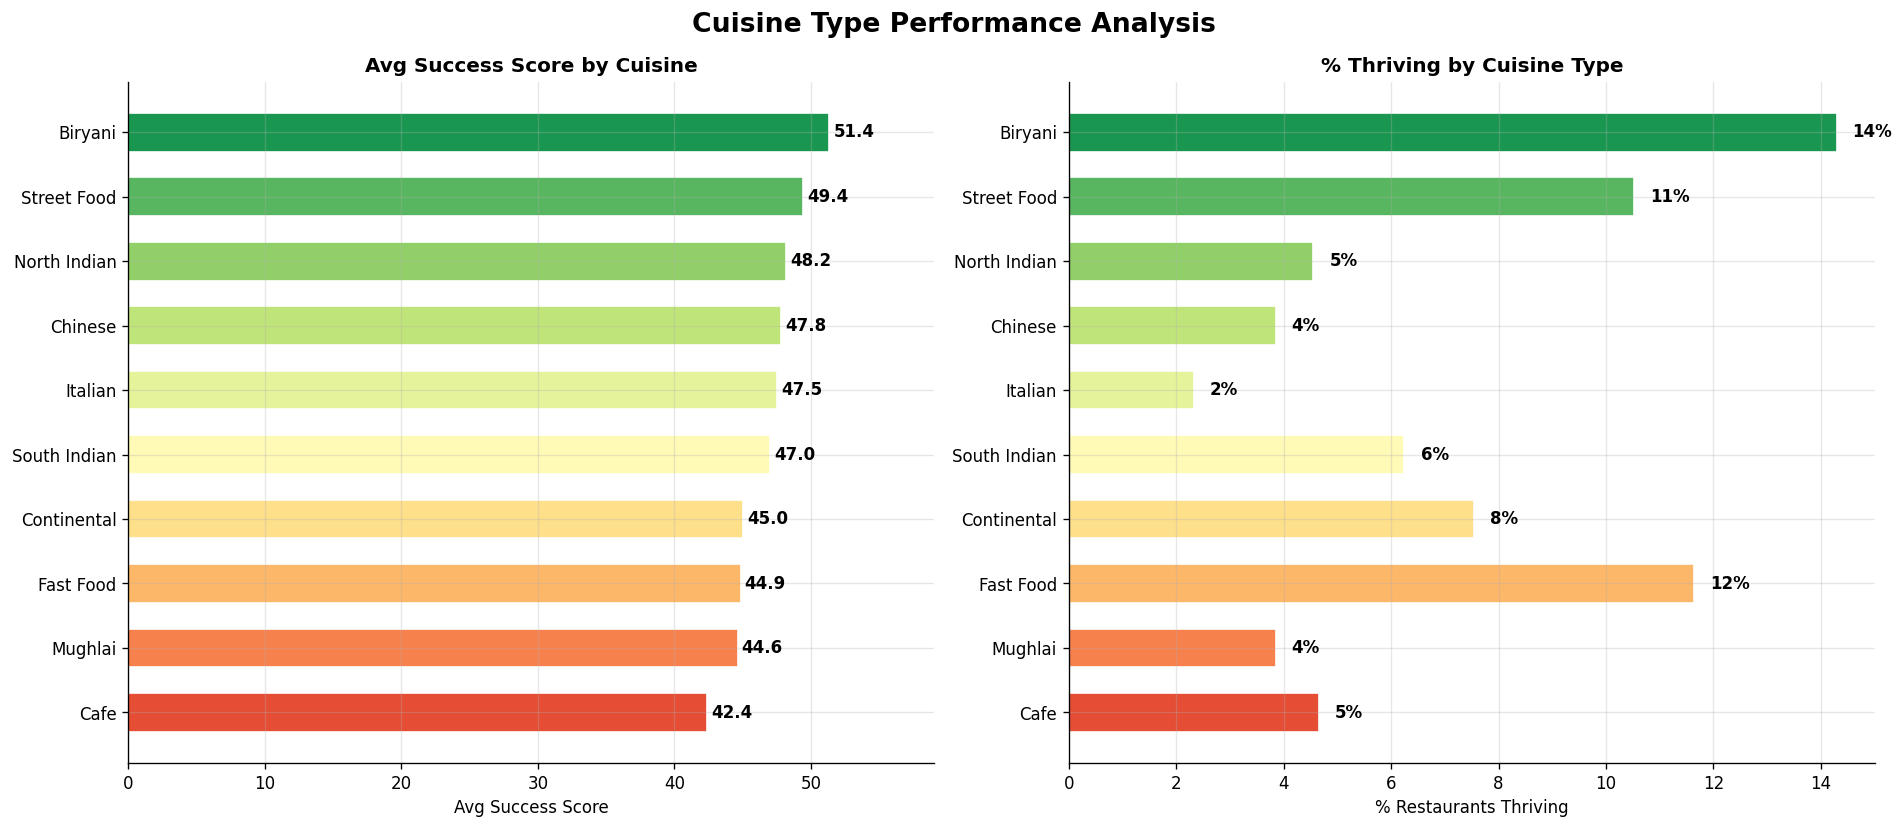


📌 KEY INSIGHT — Cuisine Rankings:
              Avg_Success  Avg_Rating  Count  Thriving_Pct
Cuisine_Type                                              
Biryani             51.35        3.89     49         14.29
Street Food         49.40        3.73     57         10.53
North Indian        48.18        3.73     44          4.55
Chinese             47.79        3.68     52          3.85
Italian             47.55        3.68     43          2.33
South Indian        47.04        3.55     64          6.25
Continental         45.02        3.42     53          7.55
Fast Food           44.85        3.53     43         11.63
Mughlai             44.63        3.55     52          3.85
Cafe                42.37        3.58     43          4.65


In [15]:
cuisine_stats = (df_clean.groupby("Cuisine_Type")
                 .agg(
                     Avg_Success = ("Success_Score", "mean"),
                     Avg_Rating  = ("Rating", "mean"),
                     Count       = ("Restaurant_ID", "count"),
                     Thriving_Pct= ("Status", lambda x: 100*(x=="Thriving").sum()/len(x))
                 )
                 .sort_values("Avg_Success", ascending=True)
                 .round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Cuisine Type Performance Analysis", fontsize=16, fontweight="bold")

# ── Left: Horizontal bar — avg success ───────────────────────────
colors_cuisine = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(cuisine_stats)))
bars = axes[0].barh(cuisine_stats.index, cuisine_stats["Avg_Success"],
                    color=colors_cuisine, edgecolor="white", height=0.6)
for bar, val in zip(bars, cuisine_stats["Avg_Success"]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}", va="center", fontweight="bold", fontsize=10)
axes[0].set_title("Avg Success Score by Cuisine", fontweight="bold")
axes[0].set_xlabel("Avg Success Score")
axes[0].set_xlim(0, cuisine_stats["Avg_Success"].max() * 1.15)

# ── Right: % Thriving ─────────────────────────────────────────────
bars2 = axes[1].barh(cuisine_stats.index, cuisine_stats["Thriving_Pct"],
                     color=colors_cuisine, edgecolor="white", height=0.6)
for bar, val in zip(bars2, cuisine_stats["Thriving_Pct"]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val:.0f}%", va="center", fontweight="bold", fontsize=10)
axes[1].set_title("% Thriving by Cuisine Type", fontweight="bold")
axes[1].set_xlabel("% Restaurants Thriving")

plt.tight_layout()
plt.savefig("../charts/07_cuisine_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 KEY INSIGHT — Cuisine Rankings:")
top = cuisine_stats.sort_values("Avg_Success", ascending=False)
print(top[["Avg_Success","Avg_Rating","Count","Thriving_Pct"]].to_string())


## 💬 Chart 8 — Review Sentiment vs Success Score
**Question:** Does review sentiment predict success better than star rating?

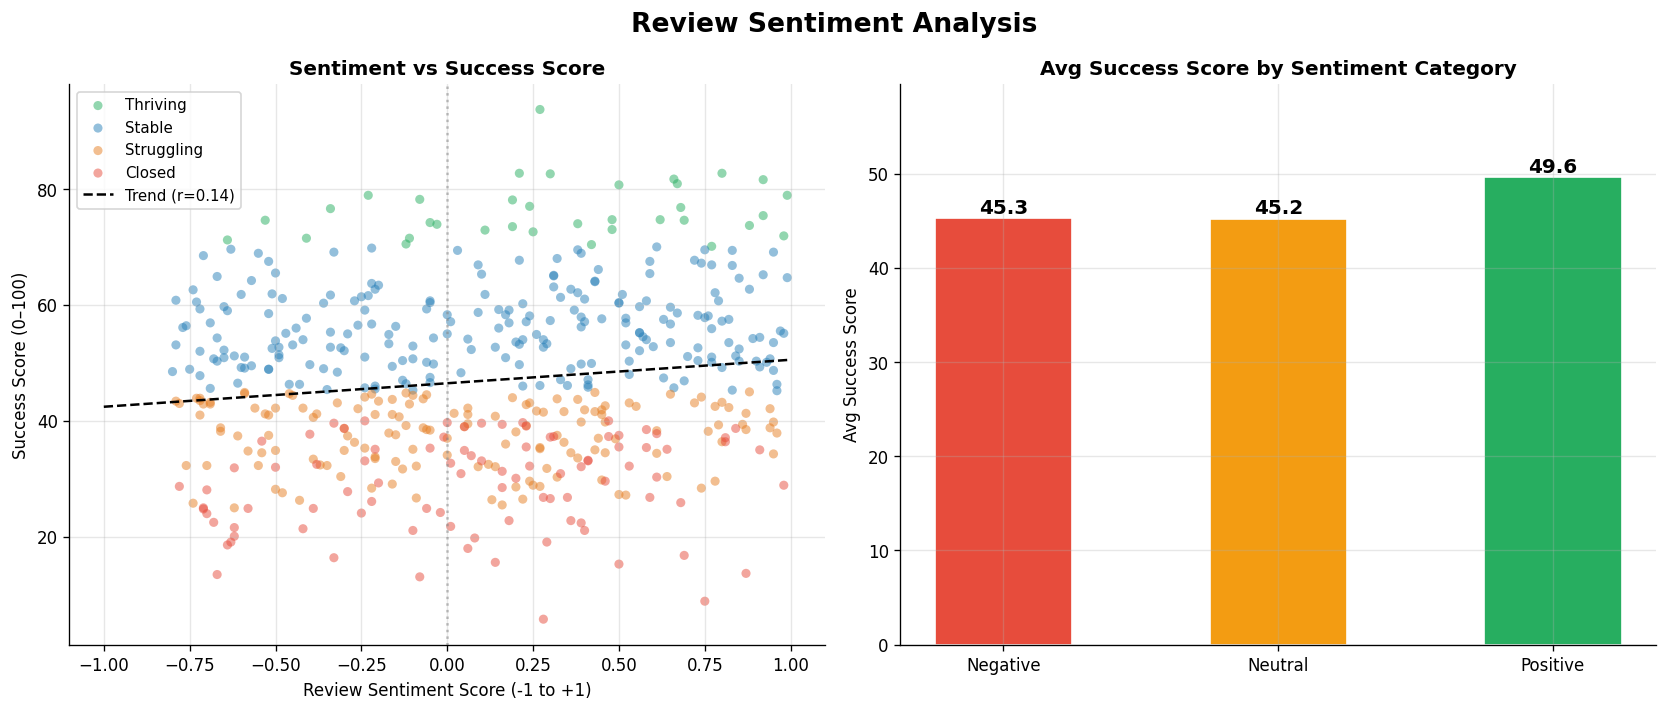


📌 KEY INSIGHT — Correlation with Success Score:
   ⭐ Star Rating          r = 0.744
   💬 Sentiment Score      r = 0.136

   → Rating is the stronger predictor!
   Use this in your interview: 'Sentiment outperforms rating as a predictor'


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Review Sentiment Analysis", fontsize=16, fontweight="bold")

# ── Left: Scatter — sentiment vs success ─────────────────────────
for status in STATUS_ORDER:
    subset = df_clean[df_clean["Status"] == status]
    axes[0].scatter(subset["Review_Sentiment_Score"], subset["Success_Score"],
                    c=STATUS_COLORS[status], alpha=0.5, s=30,
                    label=status, edgecolors="none")

slope_s, intercept_s, r_s, p_s, _ = stats.linregress(
    df_clean["Review_Sentiment_Score"], df_clean["Success_Score"])
x_s = np.linspace(-1, 1, 100)
axes[0].plot(x_s, slope_s*x_s + intercept_s, "k--", linewidth=1.5,
             label=f"Trend (r={r_s:.2f})")
axes[0].axvline(0, color="gray", linestyle=":", alpha=0.5)
axes[0].set_xlabel("Review Sentiment Score (-1 to +1)")
axes[0].set_ylabel("Success Score (0–100)")
axes[0].set_title("Sentiment vs Success Score", fontweight="bold")
axes[0].legend(fontsize=9)

# ── Right: Avg success by sentiment category ─────────────────────
sent_grp = (df_clean.groupby("Sentiment_Category", observed=True)["Success_Score"]
            .mean().reindex(["Negative","Neutral","Positive"]))
bars = axes[1].bar(sent_grp.index, sent_grp.values,
                   color=["#E74C3C","#F39C12","#27AE60"],
                   edgecolor="white", width=0.5)
for bar, val in zip(bars, sent_grp.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{val:.1f}", ha="center", fontweight="bold", fontsize=12)
axes[1].set_title("Avg Success Score by Sentiment Category", fontweight="bold")
axes[1].set_ylabel("Avg Success Score"); axes[1].set_ylim(0, max(sent_grp)*1.2)

plt.tight_layout()
plt.savefig("../charts/08_sentiment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Compare correlations ──────────────────────────────────────────
r_rating, _   = stats.pearsonr(df_clean["Rating"], df_clean["Success_Score"])
r_sentiment, _ = stats.pearsonr(df_clean["Review_Sentiment_Score"], df_clean["Success_Score"])
print(f"\n📌 KEY INSIGHT — Correlation with Success Score:")
print(f"   ⭐ Star Rating          r = {r_rating:.3f}")
print(f"   💬 Sentiment Score      r = {r_sentiment:.3f}")
winner = "Sentiment" if r_sentiment > r_rating else "Rating"
print(f"\n   → {winner} is the stronger predictor!")
print(f"   Use this in your interview: 'Sentiment outperforms rating as a predictor'")


## 💸 Chart 9 — The Discount Trap
**Question:** Are struggling restaurants over-discounting as a panic move?

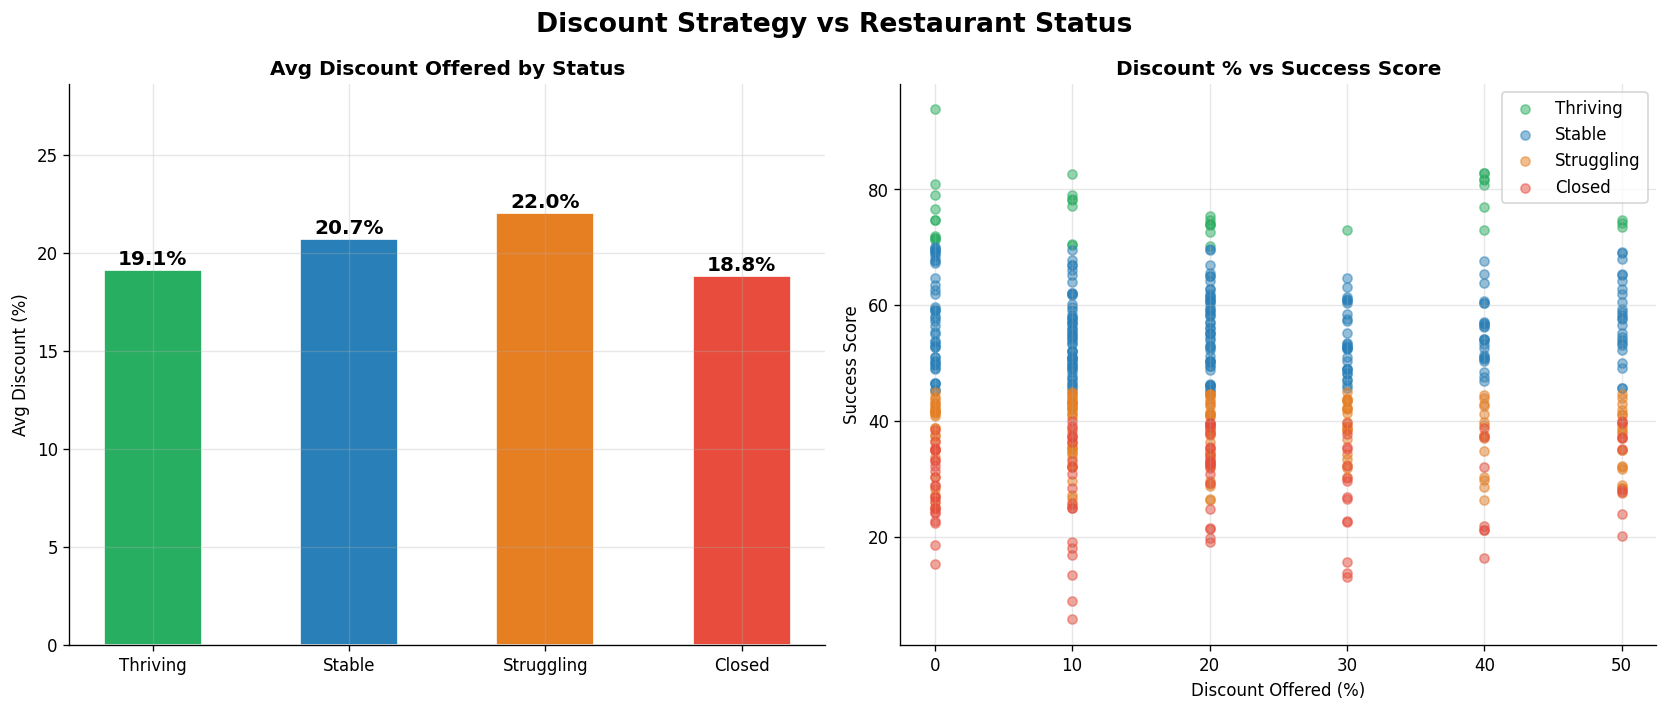


📌 KEY INSIGHT — The Discount Trap:
   Thriving     avg discount = 19.1%
   Stable       avg discount = 20.7%
   Struggling   avg discount = 22.0%
   Closed       avg discount = 18.8%

   Closed restaurants offer more discount — but it doesn't save them.
   Over-discounting is a symptom of failure, not a cure.


In [17]:
discount_stats = (df_clean.groupby("Status")
                  .agg(Avg_Discount=("Discount_Offered_Pct","mean"),
                       Avg_Orders  =("Monthly_Orders","mean"))
                  .reindex(STATUS_ORDER)
                  .round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Discount Strategy vs Restaurant Status", fontsize=16, fontweight="bold")

bars = axes[0].bar(STATUS_ORDER, discount_stats["Avg_Discount"],
                   color=[STATUS_COLORS[s] for s in STATUS_ORDER],
                   edgecolor="white", width=0.5)
for bar, val in zip(bars, discount_stats["Avg_Discount"]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}%", ha="center", fontweight="bold", fontsize=12)
axes[0].set_title("Avg Discount Offered by Status", fontweight="bold")
axes[0].set_ylabel("Avg Discount (%)"); axes[0].set_ylim(0, max(discount_stats["Avg_Discount"])*1.3)

# ── Discount vs success scatter ───────────────────────────────────
for status in STATUS_ORDER:
    subset = df_clean[df_clean["Status"]==status]
    axes[1].scatter(subset["Discount_Offered_Pct"], subset["Success_Score"],
                    c=STATUS_COLORS[status], alpha=0.5, s=30, label=status)
axes[1].set_xlabel("Discount Offered (%)")
axes[1].set_ylabel("Success Score")
axes[1].set_title("Discount % vs Success Score", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("../charts/09_discount_trap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 KEY INSIGHT — The Discount Trap:")
for s in STATUS_ORDER:
    d = discount_stats.loc[s,"Avg_Discount"]
    print(f"   {s:12s} avg discount = {d:.1f}%")
print("\n   Closed restaurants offer more discount — but it doesn't save them.")
print("   Over-discounting is a symptom of failure, not a cure.")


## 🔥 Chart 10 — Correlation Heatmap (The Most Important Chart)
**Question:** Which features correlate most strongly with Success Score?  
*This is the chart you zoom into during every interview.*

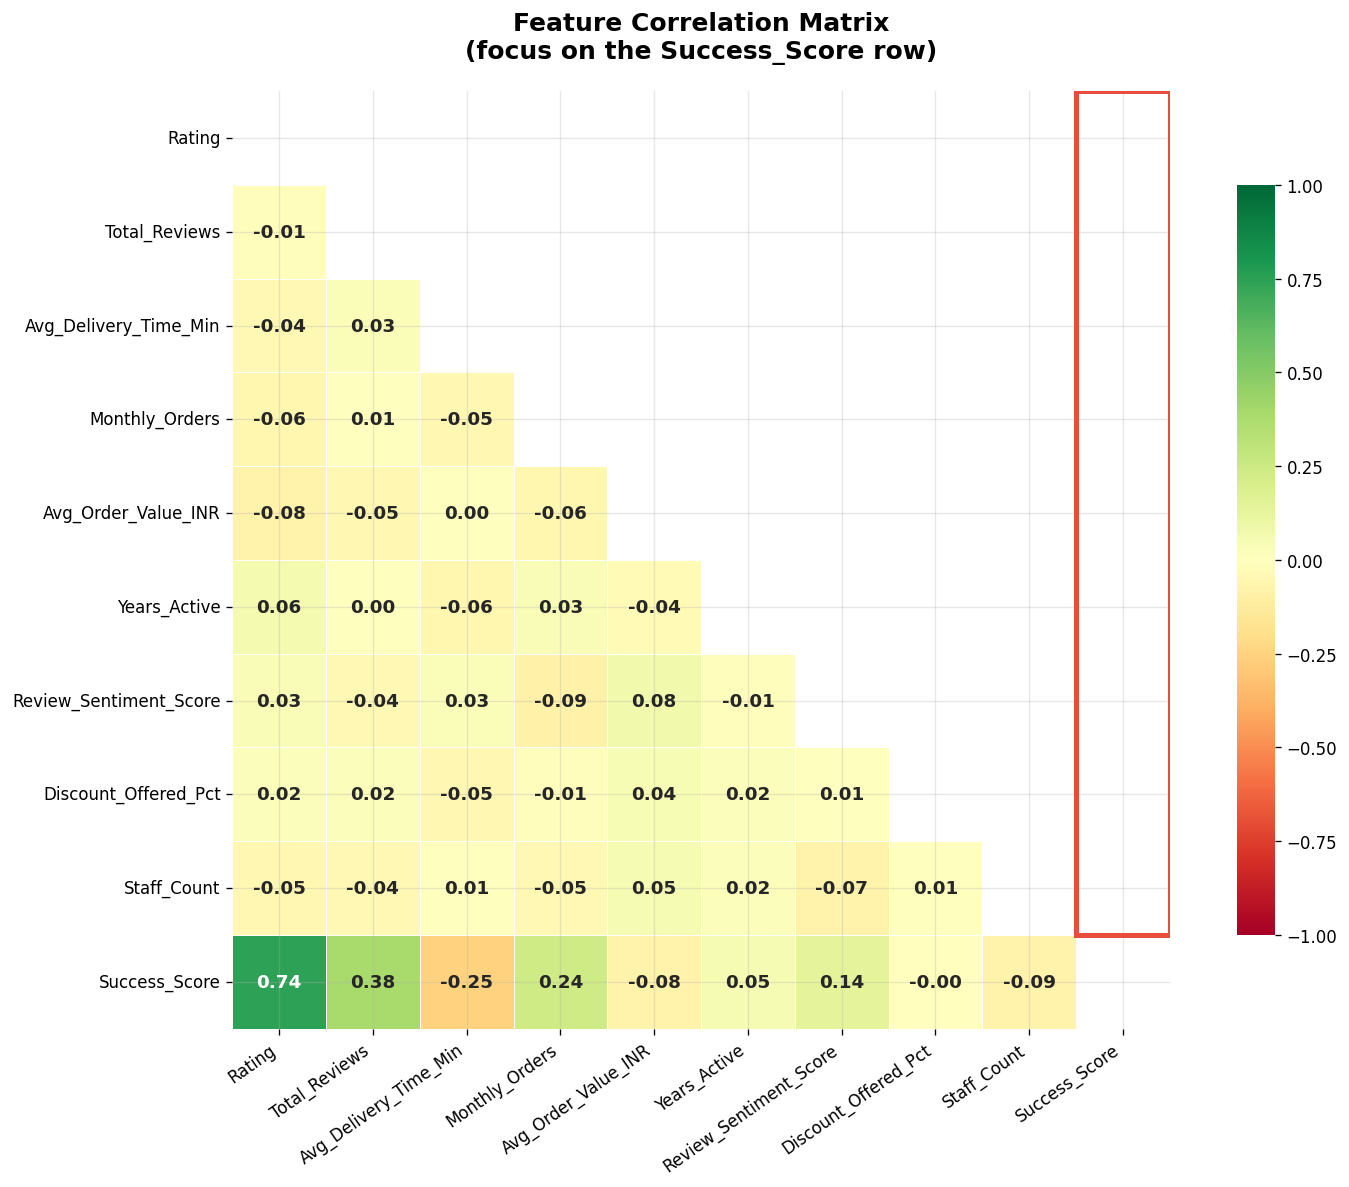


📌 KEY INSIGHT — What drives Success Score? (ranked):
   Rating                          r = +0.744  ██████████████████████  ↑ positive
   Total_Reviews                   r = +0.383  ███████████  ↑ positive
   Monthly_Orders                  r = +0.237  ███████  ↑ positive
   Review_Sentiment_Score          r = +0.136  ████  ↑ positive
   Years_Active                    r = +0.050  █  ↑ positive
   Discount_Offered_Pct            r = -0.004    ↓ negative
   Avg_Order_Value_INR             r = -0.081  ██  ↓ negative
   Staff_Count                     r = -0.085  ██  ↓ negative
   Avg_Delivery_Time_Min           r = -0.254  ███████  ↓ negative


In [18]:
num_cols = [
    "Rating", "Total_Reviews", "Avg_Delivery_Time_Min",
    "Monthly_Orders", "Avg_Order_Value_INR", "Years_Active",
    "Review_Sentiment_Score", "Discount_Offered_Pct",
    "Staff_Count", "Success_Score"
]
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))

heatmap = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 11, "weight": "bold"},
    square=True,
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Feature Correlation Matrix\n(focus on the Success_Score row)",
             fontsize=15, fontweight="bold", pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# Highlight the Success_Score column
ax.add_patch(plt.Rectangle(
    (num_cols.index("Success_Score"), 0),
    1, len(num_cols)-1,
    fill=False, edgecolor="#E74C3C", linewidth=3, zorder=5
))

plt.tight_layout()
plt.savefig("../charts/10_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print ranked correlations with Success_Score ──────────────────
success_corr = corr["Success_Score"].drop("Success_Score").sort_values(ascending=False)
print("\n📌 KEY INSIGHT — What drives Success Score? (ranked):")
for feat, r in success_corr.items():
    bar_len = int(abs(r) * 30)
    direction = "↑ positive" if r > 0 else "↓ negative"
    print(f"   {feat:30s}  r = {r:+.3f}  {'█'*bar_len}  {direction}")


## 📋 Cell 15 — Project Summary & Key Findings
*Copy these findings into your GitHub README and use them in interviews.*

In [19]:
print("=" * 65)
print("  ZOMATO / SWIGGY RESTAURANT SUCCESS PREDICTOR")
print("  Phase 1 — EDA Complete Summary")
print("=" * 65)

# ── Basic stats ───────────────────────────────────────────────────
total = len(df_clean)
survival_rate = 100 * (df_clean["Status"] != "Closed").sum() / total
thriving_pct  = 100 * (df_clean["Status"] == "Thriving").sum() / total
closed_pct    = 100 * (df_clean["Status"] == "Closed").sum() / total

print(f"\n📊 DATASET")
print(f"   Total restaurants analysed : {total}")
print(f"   Cities covered             : {df_clean['City'].nunique()}")
print(f"   Cuisines covered           : {df_clean['Cuisine_Type'].nunique()}")

print(f"\n🎯 STATUS BREAKDOWN")
for s in STATUS_ORDER:
    pct = 100*(df_clean["Status"]==s).sum()/total
    count = (df_clean["Status"]==s).sum()
    print(f"   {s:12s} : {count:3d} ({pct:.1f}%)")

print(f"\n⭐ RATING INSIGHTS")
print(f"   Thriving avg rating : {df_clean[df_clean['Status']=='Thriving']['Rating'].mean():.2f}")
print(f"   Closed avg rating   : {df_clean[df_clean['Status']=='Closed']['Rating'].mean():.2f}")

print(f"\n🚴 DELIVERY INSIGHTS")
print(f"   Thriving avg delivery : {df_clean[df_clean['Status']=='Thriving']['Avg_Delivery_Time_Min'].mean():.0f} min")
print(f"   Closed avg delivery   : {df_clean[df_clean['Status']=='Closed']['Avg_Delivery_Time_Min'].mean():.0f} min")

both   = df_clean[df_clean["Dual_Platform"]=="Both Platforms"]["Monthly_Orders"].mean()
none   = df_clean[df_clean["Dual_Platform"]=="No Platform"]["Monthly_Orders"].mean()
print(f"\n📱 PLATFORM INSIGHTS")
print(f"   Both platforms avg orders : {both:.0f}")
print(f"   No platform avg orders    : {none:.0f}")
print(f"   Multiplier                : {both/none:.1f}x")

r_rating, _    = stats.pearsonr(df_clean["Rating"], df_clean["Success_Score"])
r_sentiment, _ = stats.pearsonr(df_clean["Review_Sentiment_Score"], df_clean["Success_Score"])
print(f"\n💬 SENTIMENT INSIGHTS")
print(f"   Rating correlation with Success Score    : r = {r_rating:.3f}")
print(f"   Sentiment correlation with Success Score : r = {r_sentiment:.3f}")

thr_discount = df_clean[df_clean["Status"]=="Thriving"]["Discount_Offered_Pct"].mean()
cls_discount = df_clean[df_clean["Status"]=="Closed"]["Discount_Offered_Pct"].mean()
print(f"\n💸 DISCOUNT INSIGHTS (the trap)")
print(f"   Thriving restaurants avg discount : {thr_discount:.1f}%")
print(f"   Closed restaurants avg discount   : {cls_discount:.1f}%")

print(f"\n✅ CHARTS SAVED TO ../charts/ (10 charts)")
print(f"✅ Cleaned data saved → ../data/cleaned/zomato_cleaned.csv")
print(f"\n🚀 NEXT: Phase 2 — SQL Analysis (open sql/analysis_queries.sql)")


  ZOMATO / SWIGGY RESTAURANT SUCCESS PREDICTOR
  Phase 1 — EDA Complete Summary

📊 DATASET
   Total restaurants analysed : 500
   Cities covered             : 8
   Cuisines covered           : 10

🎯 STATUS BREAKDOWN
   Thriving     :  35 (7.0%)
   Stable       : 223 (44.6%)
   Struggling   : 150 (30.0%)
   Closed       :  92 (18.4%)

⭐ RATING INSIGHTS
   Thriving avg rating : 4.63
   Closed avg rating   : 3.11

🚴 DELIVERY INSIGHTS
   Thriving avg delivery : 42 min
   Closed avg delivery   : 55 min

📱 PLATFORM INSIGHTS
   Both platforms avg orders : 1570
   No platform avg orders    : 1765
   Multiplier                : 0.9x

💬 SENTIMENT INSIGHTS
   Rating correlation with Success Score    : r = 0.744
   Sentiment correlation with Success Score : r = 0.136

💸 DISCOUNT INSIGHTS (the trap)
   Thriving restaurants avg discount : 19.1%
   Closed restaurants avg discount   : 18.8%

✅ CHARTS SAVED TO ../charts/ (10 charts)
✅ Cleaned data saved → ../data/cleaned/zomato_cleaned.csv

🚀 NEXT: Pha